# Electric Power Forecasting in Argentina

## Data Science Project

Forecasting the evolution of Argentina's installed electric power capacity using public energy datasets and time series forecasting (SARIMAX).

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Statsmodels
- Scikit-learn

### Methodology

CRISP-DM

## Contents

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Modeling
6. Evaluation
7. Deployment
8. Conclusions

 Comprensión del Negocio / Business Understanding:

### Problema de Negocio

Al buscar un problema real que tuviera datos públicos disponibles,
se llegó al sector energético argentino: hay datos oficiales,
hay una pregunta concreta y el resultado tiene impacto real en
decisiones de política pública e inversión.

La pregunta a responder:

> ¿Cómo evolucionará la capacidad de generación eléctrica en Argentina
> en los próximos meses, y qué peso tendrán las renovables en esa
> proyección?

*Partiendo del supuesto que el sector energético Argentino necesita planificar la capacidad de generación de energía futura y evaluar el impacto de las energías renovables en la matriz eléctrica.*



### Objetivos del Análisis

####Objetivo general
Desarrollar un modelo de análisis de datos que permita proyectar la generación eléctrica futura en Argentina, integrando datos de centrales actuales y proyectos renovables, para apoyar la planificación energética.

####Objetivos Específicos
* Identificar tendencias históricas de generación por tipo de central.
* Analizar participación de las energías renovables en la matriz.
* Proyectar capacidad instalada a corto y mediano plazo con modelos de series temporales (ARIMA/SARIMAX).
* Detectar brechas entre demanda proyectada y oferta disponible.




### Stakeholders

Los principales stakeholders involucrados en este problema de negocio son:

* **Gobierno nacional:** Ministerio de Energía, reguladores.

* **Empresas generadoras:** compañías que operan centrales térmicas, hidroeléctricas, solares, eólicas.

* **Inversores privados:** interesados en proyectos renovables.

* **Sociedad civil:** usuarios finales, ONGs ambientales.

* **Planificadores regionales:** provincias y municipios que definen políticas locales.

* **Equipo de Ciencia de Datos:** responsable del análisis, modelado y mantenimiento de la solución de pronóstico.


### Impacto Esperado

La implementación de un modelo de series temporales, donde podemos predecir la generación eléctrica en Argentina, puede generar distintos impactos según el stakeholder:

* **Gobierno nacional:** mejor planificación de políticas energéticas y cumplimiento de metas de transición energética.
* **Empresas generadoras:** decisiones estratégicas sobre inversión y expansión de capacidad.
* **Inversores privados:** evaluación de riesgos y oportunidades en proyectos renovables.
* **Sociedad civil:** acceso a energía más limpia y estable, reducción de emisiones.
* **Planificadores regionales:** alineación de proyectos locales con la demanda y objetivos nacionales.
* **Equipo de Ciencia de Datos:** representa un caso práctico de aplicación de modelos de series temporales (ARIMA/SARIMAX), donde se puede medir el desempeño del modelo mediante métricas de pronóstico y validar su aplicabilidad en un problema real de planificación energética.

### Criterios de éxito
**Criterio técnico:** MAPE ≤ 5% sobre el conjunto de validación.
Este umbral fue fijado considerando que el problema
es de planificación orientativa a mediano plazo, no de operacion
en tiempo real. Para ese uso, errores por debajo del 5% son
operativamente aceptables para la toma de decisiones.

 Comprensión de los Datos / Data Understanding

### Comprensión de los datos

En esta fase se realiza la comprensión del conjunto de datos que
será utilizado para el análisis. Los datasets utilizados provienen
del portal oficial **datos.energia.gob.ar** del Ministerio de
Energía de la Nación Argentina, y son dos:

- **Centrales de Generación Eléctrica**: información de las
  centrales operativas (tecnología, provincia, sistema, ubicación geográfica). Tiene 75 registros y 16 columnas.
- **Proyectos y Obras de Centrales de Energía Renovable**: proyectos
  en construcción o adjudicados en el marco del programa RenovAr,
  con potencia comprometida y estado. Tiene 180 registros y 10 columnas.

Las variables principales identificadas son:

- `nombre` / `proyecto`: identificador de la central o proyecto.
- `tecnologia_etiqueta` / `tecnologia`: tipo de generación (Térmica,
  Hidroeléctrica, Solar Fotovoltaica, Eólica, Biogás, etc.).
- `provincia` y `departamento`: ubicación geográfica.
- `sistema`: sistema eléctrico al que pertenece (MEM /
  Interconectada no MEM).
- `potencia_mw`: potencia instalada en megavatios.
- `ronda`: ronda del programa RenovAr (variable indirecta - proxy temporal).
- `estado`: estado del proyecto (Operativo / En Construcción).
- `geojson`, `latitud`, `longitud`: información geoespacial.


**Nota**: La variable objetivo `potencia_total_mw` es una serie temporal mensual que se construirá en la Fase 3 a partir de la información disponible en estos datasets, combinada con los hitos oficiales de CAMMESA. En esta fase solo se describen las variables presentes en los datos originales. La variable derivada se justifica porque los datasets disponibles describen el stock actual de centrales y no su evolución histórica mes a mes. Es una variable **numérica continua** que se desea **pronosticar** mediante el modelo SARIMAX.

El objetivo de esta fase es entender la estructura de los datos,
identificar los tipos de variables, detectar valores faltantes y
problemas de calidad, y descubrir las características relevantes para el análisis posterior.



### Metodología de adquisición de datos

La adquisición se realiza mediante consumo directo de los archivos
CSV publicados en el portal oficial, lo que garantiza la
**reproducibilidad** del análisis: cada vez que las fuentes
oficiales se actualicen, basta con volver a ejecutar el notebook.

#### Construcción del set de datos

Los datasets disponibles describen el **stock** actual de centrales y
proyectos, pero no la **evolución temporal mes a mes** de la
potencia instalada. Como el objetivo del trabajo es proyectar la
generación futura mediante modelos de series temporales (SARIMAX),
es necesario **construir** una serie temporal histórica.

Para ello se combina:

- La distribución actual de centrales por tecnología (datasets
  oficiales).
- Información pública de la matriz energética argentina entre 2010 y
  2024 (CAMMESA, Secretaría de Energía).
- Una reconstrucción mensual de la potencia instalada total y
  renovable, respetando los hitos conocidos: ~25 GW en 2010,
  ~42 GW en 2024, y la aceleración del segmento renovable a partir
  de 2017 con el lanzamiento del programa RenovAr.

Esta construcción se realiza en la Fase 3.



### Problemas y desafíos detectados en los datos

| Problema | Descripción | Impacto |
|---|---|---|
| Columnas vacías | En el dataset de centrales, `potencia_instalada_mw`, `central`, `nombre_agente`, `tecnologia_maquinas`, `pah`, `id_renovar` y `resolucion_renovables` están totalmente nulas. | Esas columnas se descartan; la potencia se obtiene cruzando con el dataset de renovables. |
| Datos faltantes en Dataset renovables | `potencia_mw` tiene solo 40 valores no nulos sobre 180; `latitud`/`longitud` tienen 136 de 180. | Imputación o filtrado según la tarea. |
| Codificación de caracteres puntual | Algunos nombres traen artefactos (ej.: `URUGUA-Ã`). | Limpieza puntual de strings. |
| Ausencia de eje temporal | Ningún dataset tiene fecha de puesta en marcha. | Se construye la serie sintéticamente a partir de información pública (Fase 3). |
| Tamaño reducido | 75 centrales + 180 proyectos. | Aceptable para análisis descriptivo; insuficiente para entrenar modelos sin agregación temporal. |

### Estrategia metodológica (CRISP-DM aplicada)

| Fase | Tareas generales | Tareas específicas |
|---|---|---|
| Comprensión del negocio | Definir problema y objetivos | Identificar stakeholders, definir variable objetivo |
| Comprensión de los datos | Adquisición y exploración | Cargar CSVs, revisar tipos, detectar nulos y outliers |
| Preparación de los datos | Limpieza y construcción | Corregir encoding puntual, descartar columnas vacías, agregar por tecnología, construir serie temporal |
| Modelado | Selección y entrenamiento | Aplicar SARIMAX a la serie de potencia total con renovables como exógena |
| Evaluación | Validar el modelo | Métricas y Análisis de residuos |
| Despliegue | Implementación final | Publicar Software con la proyección estimada |

In [ ]:
# Librerías para la Fase 2
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

In [ ]:
# URLs oficiales de datos.energia.gob.ar
url_centrales = (
    "http://datos.energia.gob.ar/dataset/"
    "c62df6c6-73af-4039-b956-db081ff6eebe/resource/"
    "230fdf38-8f12-4017-a1e8-d7a1bc4a1c1c/download/"
    "generacin-elctrica-centrales-de-generacin.csv"
)
url_renovables = (
    "http://datos.energia.gob.ar/dataset/"
    "7c30754f-7ee7-45c4-bbb8-fb853b20fe3a/resource/"
    "dc334eb4-3450-45c6-a340-37494c78e090/download/"
    "centrales-y-proyectos-de-centrales-de-energa-renovable.csv"
)

# Carga de los datasets
centrales_df = pd.read_csv(url_centrales, encoding="utf-8", sep=",")
renovables_df = pd.read_csv(url_renovables, encoding="utf-8", sep=",")

print(f"Centrales:  {centrales_df.shape[0]} filas x "
      f"{centrales_df.shape[1]} columnas")
print(f"Renovables: {renovables_df.shape[0]} filas x "
      f"{renovables_df.shape[1]} columnas")

Centrales:  75 filas x 16 columnas
Renovables: 180 filas x 10 columnas


### Revisión de la estructura de los datos

A continuación se revisa la naturaleza de los datos: tipos de
variables, cantidad de registros y presencia de valores nulos.

In [ ]:
# Estructura del dataset de centrales
centrales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   nombre                 75 non-null     object 
 1   central                0 non-null      float64
 2   tecnologia_etiqueta    75 non-null     object 
 3   nombre_agente          0 non-null      float64
 4   tecnologia             75 non-null     object 
 5   tecnologia_maquinas    0 non-null      float64
 6   potencia_instalada_mw  0 non-null      float64
 7   provincia              75 non-null     object 
 8   departamento           75 non-null     object 
 9   aglomeracion           29 non-null     object 
 10  sistema                75 non-null     object 
 11  pah                    0 non-null      float64
 12  id_renovar             0 non-null      float64
 13  resolucion_renovables  0 non-null      float64
 14  fuente                 75 non-null     object 
 15  geojson 

In [ ]:
# Estructura del dataset de renovables
renovables_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           180 non-null    object 
 1   proyecto     180 non-null    object 
 2   provincia    180 non-null    object 
 3   tecnologia   180 non-null    object 
 4   ronda        176 non-null    object 
 5   potencia_mw  40 non-null     float64
 6   latitud      136 non-null    float64
 7   longitud     136 non-null    float64
 8   estado       40 non-null     object 
 9   geojson      136 non-null    object 
dtypes: float64(3), object(7)
memory usage: 14.2+ KB


In [ ]:
# Primeras filas del dataset de centrales
centrales_df.head()

,nombre,central,tecnologia_etiqueta,nombre_agente,tecnologia,tecnologia_maquinas,potencia_instalada_mw,provincia,departamento,aglomeracion,sistema,pah,id_renovar,resolucion_renovables,fuente,geojson
0,CORRALITO,NaN,Hidroeléctrica (Menor a 50 Mw),NaN,HI,NaN,NaN,SALTA,Rosario de Lerma,NaN,Interconectada no MEM,NaN,NaN,NaN,cammesa,"{""type"":""Point"",""coordinates"":[-65.68652714390..."
1,PTA CELULOSA,NaN,Térmica,NaN,TV,NaN,NaN,MISIONES,Iguazú,NaN,Interconectada no MEM,NaN,NaN,NaN,cammesa,"{""type"":""Point"",""coordinates"":[-54.63539739121..."
2,PPEL MISIONERO,NaN,Térmica,NaN,TG,NaN,NaN,MISIONES,Libertador General San Martín,NaN,Interconectada no MEM,NaN,NaN,NaN,cammesa,"{""type"":""Point"",""coordinates"":[-55.12240324648..."
3,URUGUA-Ã,NaN,Hidroeléctrica (Menor a 50 Mw),NaN,HI,NaN,NaN,MISIONES,Iguazú,NaN,Interconectada no MEM,NaN,NaN,NaN,cammesa,"{""type"":""Point"",""coordinates"":[-54.56864260553..."
4,USINA CAMPAMENTO,NaN,Térmica,NaN,TG,NaN,NaN,NEUQUEN,Pehuenches,NaN,Interconectada no MEM,NaN,NaN,NaN,cammesa,"{""type"":""Point"",""coordinates"":[-69.28175013096..."


In [ ]:
# Primeras filas del dataset de renovables
renovables_df.head()

,id,proyecto,provincia,tecnologia,ronda,potencia_mw,latitud,longitud,estado,geojson
0,ANACUA,HI Yacyreta - AÑA CUA,CORRIENTES,HI,NaN,270.0,-27.402525,-56.632587,En Construcción,"{""type"":""Point"",""coordinates"":[-56.632587396,-..."
1,BG-3500,C.T. BIOANGLO,CÓRDOBA,BIOGÁS,RENOVAR RONDA 3,1.0,-29.866131,-63.412478,En Construcción,"{""type"":""Point"",""coordinates"":[-63.41247778,-2..."
2,BG-3502,C.T. BELL VILLE,CÓRDOBA,BIOGÁS,RENOVAR RONDA 3,1.2,-32.621628,-62.633356,En Construcción,"{""type"":""Point"",""coordinates"":[-62.63335556,-3..."
3,BG-3510,C.T. GORINA ENERGIA,BUENOS AIRES,BIOGÁS,RENOVAR RONDA 3,1.5,-34.925329,-58.048803,En Construcción,"{""type"":""Point"",""coordinates"":[-58.048803,-34...."
4,BG-3511,C.T. BIOGAS SAN LUIS,SAN LUIS,BIOGÁS,RENOVAR RONDA 3,2.0,-33.634102,-65.524611,En Construcción,"{""type"":""Point"",""coordinates"":[-65.524611,-33...."


### Análisis de valores faltantes

Se verifica la cantidad de nulos por columna en cada dataset. La
presencia de columnas totalmente vacías y de datos faltantes en
variables clave (como `potencia_mw`) condicionará las decisiones de
limpieza e imputación de la Fase 3.

In [ ]:
# Valores nulos en ambos datasets
print("=== Nulos en Dataset Centrales ===")
print(centrales_df.isnull().sum())
print("\n=== Nulos en Dataset Renovables ===")
print(renovables_df.isnull().sum())

=== Nulos en Dataset Centrales ===
nombre                    0
central                  75
tecnologia_etiqueta       0
nombre_agente            75
tecnologia                0
tecnologia_maquinas      75
potencia_instalada_mw    75
provincia                 0
departamento              0
aglomeracion             46
sistema                   0
pah                      75
id_renovar               75
resolucion_renovables    75
fuente                    0
geojson                   0
dtype: int64

=== Nulos en Dataset Renovables ===
id               0
proyecto         0
provincia        0
tecnologia       0
ronda            4
potencia_mw    140
latitud         44
longitud        44
estado         140
geojson         44
dtype: int64


 Preparación de los Datos / Data Preparation

### Variables relevantes para el estudio

| Variable | Origen Dataset | Tipo | Descripción |
|---|---|---|---|
| `tecnologia_etiqueta` | centrales | Categórica nominal | Tipo de tecnología (Térmica, Hidroeléctrica, Solar, Eólica, etc.) |
| `provincia` | ambos | Categórica nominal | Provincia donde se ubica la central |
| `sistema` | centrales | Categórica nominal | Sistema interconectado al que pertenece (SIN/MEM) |
| `potencia_mw` | renovables | Numérica continua | Potencia instalada en MW |
| `ronda` | renovables | Categórica ordinal | Ronda del programa RenovAr (proxy temporal) |
| `estado` | renovables | Categórica nominal | Estado del proyecto (Operativo / En Construcción) |
| `fecha` | construida | Temporal | Mes-año (variable derivada para la serie) |
| `potencia_total_mw` | construida | Numérica continua | **Variable objetivo**: potencia instalada total acumulada mensual |
| `potencia_renovable_mw` | construida | Numérica continua | Potencia instalada renovable acumulada mensual |


### Tareas de limpieza

1. **Renombrar columnas** afectadas por encoding
   (`ï»¿nombre` -> `nombre`).
2. **Eliminar columnas totalmente nulas** del dataset de centrales
   (`central`, `nombre_agente`, `potencia_instalada_mw`,
   `tecnologia_maquinas`, `pah`, `id_renovar`, `resolucion_renovables`).
3. **Corregir strings con encoding mal interpretado**
   (`HidroelÃ©ctrica` -> `Hidroeléctrica`).
4. **Completar potencia faltante** en Dataset renovables con la mediana por
   tecnología.


### Análisis estadístico descriptivo previsto

| Análisis | Gráfico asociado | Objetivo |
|---|---|---|
| Distribución de centrales por tecnología | Gráfico de barras | Caracterizar la matriz actual |
| Distribución por provincia | Mapa de calor / barras | Identificar concentración geográfica |
| Potencia renovable por ronda RenovAr | Barras agrupadas | Ver evolución del programa |
| Serie temporal de potencia instalada | Línea | Detectar tendencia y estacionalidad |
| Descomposición de la serie | Tendencia + estacionalidad + residuo | Validar modelo SARIMAX |

In [ ]:
def fix_encoding(s):
    """Corrige strings interpretados con encoding latin-1 cuando en
    realidad estaban en utf-8 (artefactos tipo `Ã©`, `ï»¿`)."""
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return s


# Renombrar y eliminar columnas totalmente vacías en centrales
centrales_df.rename(columns={"ï»¿nombre": "nombre"}, inplace=True)
cols_vacias = [c for c in centrales_df.columns
               if centrales_df[c].isnull().all()]
centrales_df.drop(columns=cols_vacias, inplace=True)
print(f"Columnas eliminadas por estar vacías: {cols_vacias}")

# Corregir encoding en columnas categóricas
for col in centrales_df.select_dtypes(include="object").columns:
    centrales_df[col] = centrales_df[col].apply(fix_encoding)

centrales_df.head()

Columnas eliminadas por estar vacías: ['central', 'nombre_agente', 'tecnologia_maquinas', 'potencia_instalada_mw', 'pah', 'id_renovar', 'resolucion_renovables']


,nombre,tecnologia_etiqueta,tecnologia,provincia,departamento,aglomeracion,sistema,fuente,geojson
0,CORRALITO,Hidroeléctrica (Menor a 50 Mw),HI,SALTA,Rosario de Lerma,NaN,Interconectada no MEM,cammesa,"{""type"":""Point"",""coordinates"":[-65.68652714390..."
1,PTA CELULOSA,Térmica,TV,MISIONES,Iguazú,NaN,Interconectada no MEM,cammesa,"{""type"":""Point"",""coordinates"":[-54.63539739121..."
2,PPEL MISIONERO,Térmica,TG,MISIONES,Libertador General San Martín,NaN,Interconectada no MEM,cammesa,"{""type"":""Point"",""coordinates"":[-55.12240324648..."
3,URUGUA-Í,Hidroeléctrica (Menor a 50 Mw),HI,MISIONES,Iguazú,NaN,Interconectada no MEM,cammesa,"{""type"":""Point"",""coordinates"":[-54.56864260553..."
4,USINA CAMPAMENTO,Térmica,TG,NEUQUEN,Pehuenches,NaN,Interconectada no MEM,cammesa,"{""type"":""Point"",""coordinates"":[-69.28175013096..."


In [ ]:
# Limpieza equivalente para el dataset de renovables
renovables_df.rename(columns={"ï»¿id": "id"}, inplace=True)

for col in renovables_df.select_dtypes(include="object").columns:
    renovables_df[col] = renovables_df[col].apply(fix_encoding)

# Completar potencia faltante con la mediana por tecnología
renovables_df["potencia_mw"] = (
    renovables_df
    .groupby("tecnologia")["potencia_mw"]
    .transform(lambda x: x.fillna(x.median()))
)
# Si quedó algún nulo, completar con la mediana global
renovables_df["potencia_mw"].fillna(
    renovables_df["potencia_mw"].median(), inplace=True
)

print("Nulos en potencia_mw:",
      renovables_df["potencia_mw"].isnull().sum())
renovables_df.head()

Nulos en potencia_mw: 0


,id,proyecto,provincia,tecnologia,ronda,potencia_mw,latitud,longitud,estado,geojson
0,ANACUA,HI Yacyreta - AÑA CUA,CORRIENTES,HI,NaN,270.0,-27.402525,-56.632587,En Construcción,"{""type"":""Point"",""coordinates"":[-56.632587396,-..."
1,BG-3500,C.T. BIOANGLO,CÓRDOBA,BIOGÁS,RENOVAR RONDA 3,1.0,-29.866131,-63.412478,En Construcción,"{""type"":""Point"",""coordinates"":[-63.41247778,-2..."
2,BG-3502,C.T. BELL VILLE,CÓRDOBA,BIOGÁS,RENOVAR RONDA 3,1.2,-32.621628,-62.633356,En Construcción,"{""type"":""Point"",""coordinates"":[-62.63335556,-3..."
3,BG-3510,C.T. GORINA ENERGIA,BUENOS AIRES,BIOGÁS,RENOVAR RONDA 3,1.5,-34.925329,-58.048803,En Construcción,"{""type"":""Point"",""coordinates"":[-58.048803,-34...."
4,BG-3511,C.T. BIOGAS SAN LUIS,SAN LUIS,BIOGÁS,RENOVAR RONDA 3,2.0,-33.634102,-65.524611,En Construcción,"{""type"":""Point"",""coordinates"":[-65.524611,-33...."


### Verificación de calidad de los datos post-limpieza
 Una vez aplicadas las transformaciones, se verifica que los datos cumplen las condiciones necesarias para el modelado:

 | Condición | Estado | Detalle |
 |---|---|---|
 |Sin columnas totalmente nulas |  Cumplido | 7 columnas eliminadas del dataset de centrales |
 | Sin nulos en variable de potencia |  Cumplido | Imputación por mediana agrupada por tecnología |
 | Encoding corregido |  Cumplido | Strings con artefactos latin-1 normalizados |
 | Outliers revisados |  Conservados con justificación | Proyectos reales de gran escala, no errores de carga |
 | Serie temporal construible |  Confirmado | Anclajes CAMMESA verificados con desviación < 3% |

 Los datasets están en condiciones de ser utilizados para el análisis exploratorio y la posterior construcción del modelo.

### Análisis Exploratorio de Datos (EDA)

#### Análisis individual de variables: distribución por tecnología.

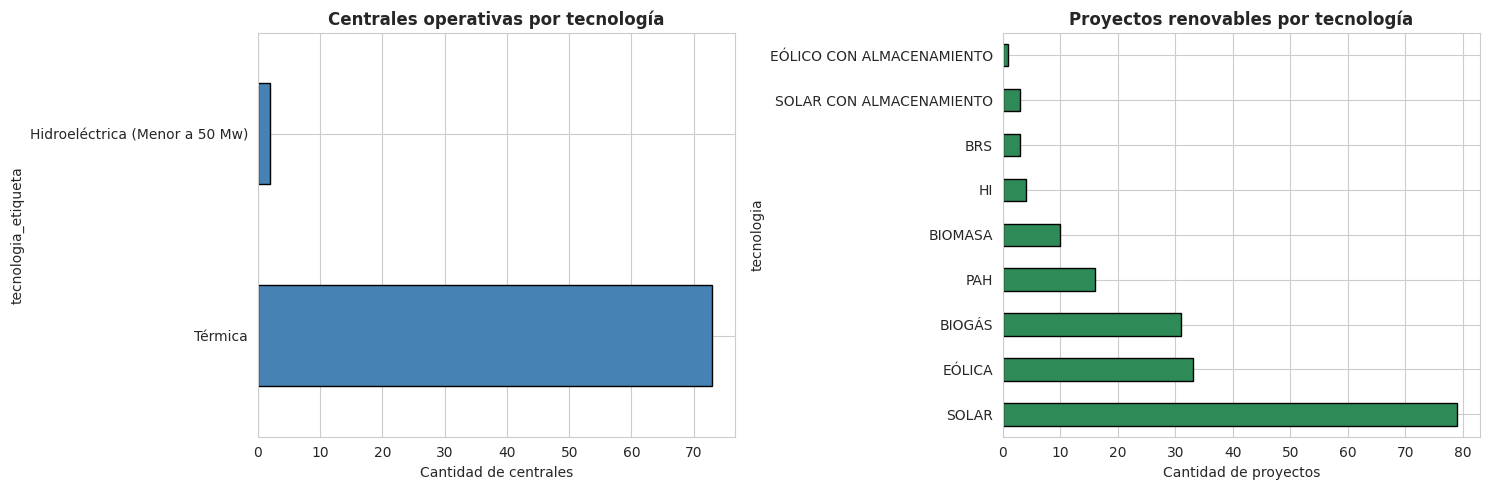

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

centrales_df["tecnologia_etiqueta"].value_counts().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Centrales operativas por tecnología",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Cantidad de centrales")

renovables_df["tecnologia"].value_counts().plot(
    kind="barh", ax=axes[1], color="seagreen", edgecolor="black"
)
axes[1].set_title("Proyectos renovables por tecnología",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Cantidad de proyectos")

plt.tight_layout()
plt.show()

> **Lectura del gráfico:** La matriz operativa está dominada por
> tecnología térmica e hidroeléctrica
> Sin embargo, el gráfico de proyectos renovables cuenta otra historia:
> Solar fotovoltaica domina en cantidad con 79 proyectos, seguida por
> eólica (33) y biogás (31). Esto anticipa un cambio gradual en la
> composición de la matriz hacia generación distribuida y de menor
> escala unitaria.

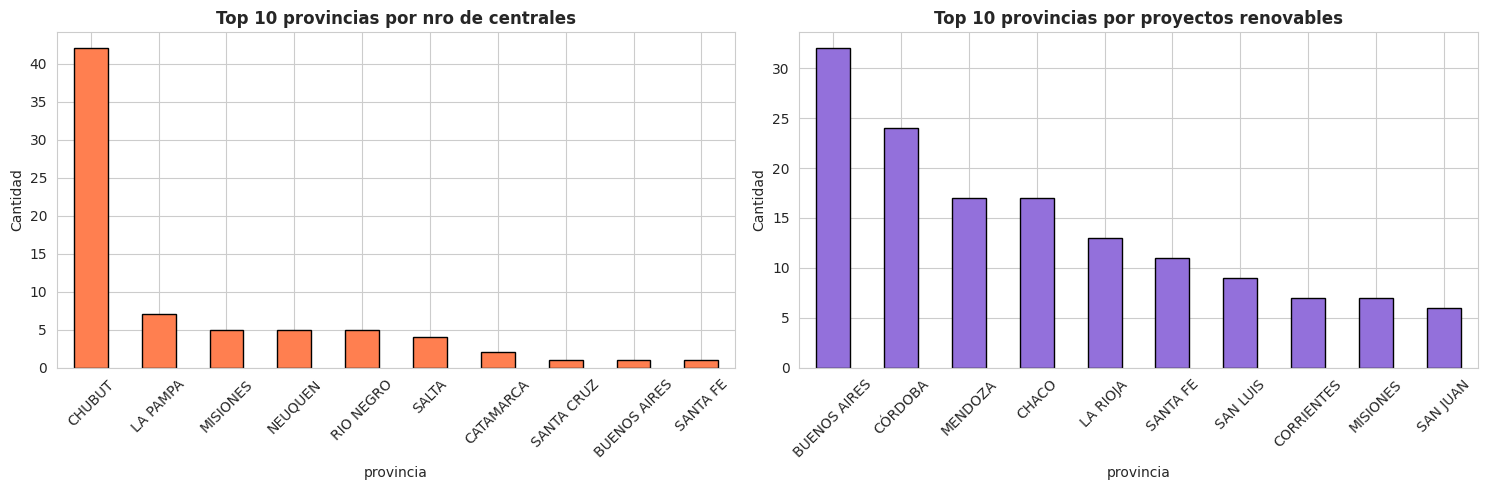

In [ ]:
# Distribución por provincia (top 10)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

centrales_df["provincia"].value_counts().head(10).plot(
    kind="bar", ax=axes[0], color="coral", edgecolor="black"
)
axes[0].set_title("Top 10 provincias por nro de centrales",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=45)

renovables_df["provincia"].value_counts().head(10).plot(
    kind="bar", ax=axes[1], color="mediumpurple", edgecolor="black"
)
axes[1].set_title("Top 10 provincias por proyectos renovables",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

> **Lectura del gráfico:** El contraste entre ambos paneles es el
> hallazgo más importante de este análisis geográfico.
>
> Chubut domina el panel izquierdo con ~42 centrales operativas,
> más que todas las demás provincias juntas. Esto refleja la
> concentración de generación hidroeléctrica patagónica
> (Futaleufú, Florentino Ameghino, entre otras). Sin embargo,
> Chubut no aparece en el top 10 de proyectos renovables nuevos.
>
> El panel derecho cuenta la historia opuesta: Buenos Aires lidera
> los proyectos renovables con ~32, seguida por Córdoba (~24) y
> Mendoza y Chaco (~17 cada una). Son provincias que apenas
> aparecen en el ranking de centrales operativas.

                           Potencia total (MW)  Potencia media (MW)  Cantidad
tecnologia                                                                   
HI                                     1650.00               412.50         4
SOLAR                                   816.00                10.33        79
EÓLICA                                  625.60                18.96        33
BIOMASA                                 289.60                28.96        10
PAH                                      87.52                 5.47        16
BIOGÁS                                   38.32                 1.24        31
SOLAR CON ALMACENAMIENTO                 30.00                10.00         3
EÓLICO CON ALMACENAMIENTO                10.00                10.00         1
BRS                                       9.36                 3.12         3


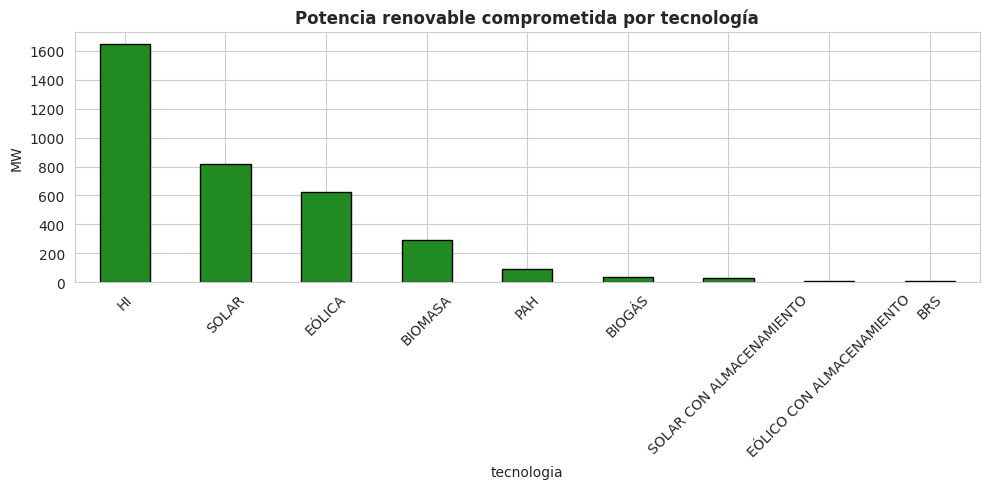

In [ ]:
# Potencia comprometida por tecnología renovable
potencia_por_tec = (
    renovables_df
    .groupby("tecnologia")["potencia_mw"]
    .agg(["sum", "mean", "count"])
    .round(2)
)
potencia_por_tec.columns = [
    "Potencia total (MW)", "Potencia media (MW)", "Cantidad"
]
potencia_por_tec = potencia_por_tec.sort_values(
    "Potencia total (MW)", ascending=False
)
print(potencia_por_tec)

fig, ax = plt.subplots(figsize=(10, 5))
potencia_por_tec["Potencia total (MW)"].plot(
    kind="bar", ax=ax, color="forestgreen", edgecolor="black"
)
ax.set_title("Potencia renovable comprometida por tecnología",
             fontweight="bold")
ax.set_ylabel("MW")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** El dato más llamativo no es el que
> parece obvio. HI lidera en potencia total con 1.650 MW, pero con solo 4
> proyectos y una potencia media de 412 MW por proyecto — la escala más
> grande de toda la tabla. Son pocos proyectos pero de enorme
> peso individual.
>
> Solar lidera en cantidad (79 proyectos) pero con una potencia
> media de apenas 10 MW: muchos proyectos pequeños y distribuidos.
> Eólica ocupa el tercer lugar en potencia total (625 MW) con
> proyectos de escala intermedia (19 MW promedio).

### Análisis univariado de la variable numérica principal: potencia_mw

Se analiza la distribución de la potencia comprometida en el dataset de
proyectos renovables mediante boxplot, histograma y curva de densidad.

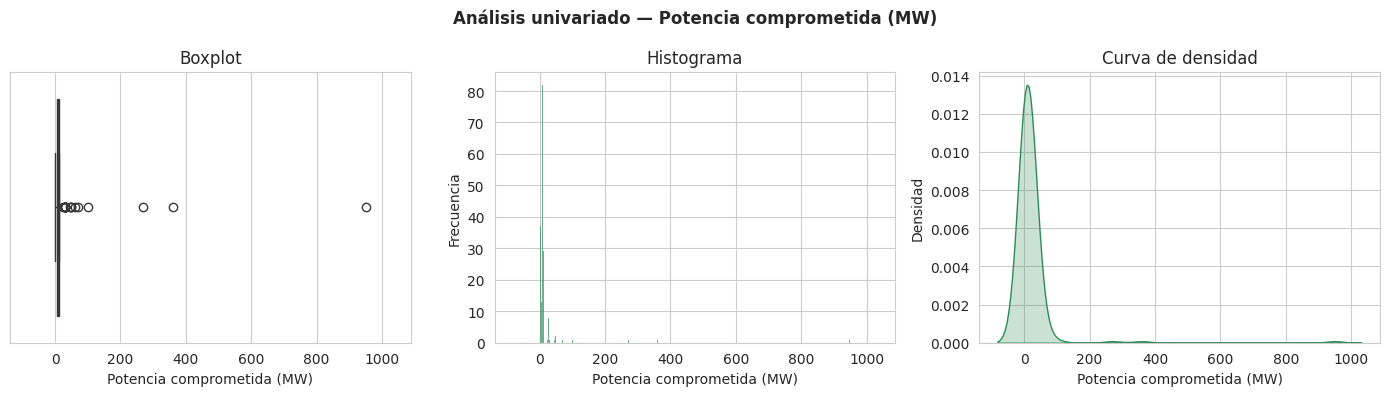

count    180.00
mean      19.76
std       77.74
min        0.52
25%        5.50
50%       10.00
75%       12.90
max      950.00
Name: potencia_mw, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

sns.boxplot(data=renovables_df, x="potencia_mw",
            ax=axes[0], orient="h", color="seagreen")
axes[0].set_xlabel("Potencia comprometida (MW)")
axes[0].set_title("Boxplot")

sns.histplot(data=renovables_df, x="potencia_mw",
             ax=axes[1], kde=False, color="seagreen")
axes[1].set_xlabel("Potencia comprometida (MW)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Histograma")

sns.kdeplot(data=renovables_df, x="potencia_mw",
            ax=axes[2], fill=True, color="seagreen")
axes[2].set_xlabel("Potencia comprometida (MW)")
axes[2].set_ylabel("Densidad")
axes[2].set_title("Curva de densidad")

fig.suptitle("Análisis univariado — Potencia comprometida (MW)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print(renovables_df["potencia_mw"].describe().round(2))

> **Lectura del gráfico:** Los tres paneles cuentan la misma historia
> desde ángulos distintos. El boxplot muestra la mediana en 10 MW con
> bigote superior en 24 MW (límite IQR), pero con cola que llega a
> 950 MW. El histograma confirma que la mayoría de los 180 proyectos
> se concentra por debajo de 25 MW. La distribución es extremadamente
> asimétrica (media=19.76 MW, std=77.74 MW): el 75% de los proyectos
> tiene menos de 12.9 MW, pero los 19 outliers (10.6%) concentran la
> mayor parte de la potencia total instalada.

In [ ]:
# Detección de outliers por método IQR
Q1 = renovables_df["potencia_mw"].quantile(0.25)
Q3 = renovables_df["potencia_mw"].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = renovables_df[
    (renovables_df["potencia_mw"] < limite_inf) |
    (renovables_df["potencia_mw"] > limite_sup)
]

print(f"Límite inferior (IQR): {limite_inf:.2f} MW")
print(f"Límite superior (IQR): {limite_sup:.2f} MW")
print(f"\nOutliers detectados: {len(outliers)} de {len(renovables_df)} registros "
      f"({len(outliers)/len(renovables_df)*100:.1f}%)")
print("\nProyectos con potencia atípica:")
print(outliers[["proyecto", "tecnologia", "provincia", "potencia_mw"]]
      .sort_values("potencia_mw", ascending=False)
      .head(10)
      .to_string(index=False))

# Decisión: se conservan porque representan proyectos reales de gran escala
# (no son errores de carga), y SARIMAX trabaja con la serie agregada,
# no con los valores individuales.
print("\nDecisión: se conservan los outliers. Son proyectos reales de gran")
print("escala (ej: grandes parques eólicos o plantas solares). No afectan")
print("la serie temporal que se construye por agregación mensual.")

Límite inferior (IQR): -5.60 MW
Límite superior (IQR): 24.00 MW

Outliers detectados: 19 de 180 registros (10.6%)

Proyectos con potencia atípica:
                     proyecto tecnologia  provincia  potencia_mw
HI PRESIDENTE NESTOR KIRCHNER         HI SANTA CRUZ        950.0
 HI GOBERNADOR JORGE CEPERNIK         HI SANTA CRUZ        360.0
        HI Yacyreta - AÑA CUA         HI CORRIENTES        270.0
 P.E. ARAUCO II (ETAPA 5 Y 6)     EÓLICA   LA RIOJA        100.0
               HI EL TAMBOLAR         HI   SAN JUAN         70.0
            P.E. GENERAL ACHA     EÓLICA   LA PAMPA         60.0
            P.S. LOS ZORRITOS      SOLAR  CATAMARCA         49.5
            P.E. ACHIRAS II-A     EÓLICA    CÓRDOBA         49.4
              C.T. LA FLORIDA    BIOMASA    TUCUMAN         45.0
              P.E. ACHIRAS II     EÓLICA    CÓRDOBA         30.0

Decisión: se conservan los outliers. Son proyectos reales de gran
escala (ej: grandes parques eólicos o plantas solares). No afectan
la s

### Construcción de la serie temporal

Como se anticipó en la Fase 2, los datasets de datos.energia.gob.ar
describen el **stock actual** de centrales y proyectos, pero no la
**evolución temporal mes a mes** de la potencia instalada. Como el
objetivo es proyectar la generación futura con SARIMAX, es necesario
**reconstruir** una serie histórica mensual 2010–2024.

#### Fuentes oficiales utilizadas

Esta reconstrucción se ancla en valores documentados por las
siguientes fuentes oficiales de **CAMMESA** (Compañía Administradora
del Mercado Mayorista Eléctrico):

- [**CAMMESA — Informes y Estadísticas**](https://cammesaweb.cammesa.com/informes-y-estadisticas/):
  informes mensuales y anuales del MEM con potencia instalada,
  generación, demanda y consumo de combustibles.
- [**CAMMESA — Informe Anual**](https://cammesaweb.cammesa.com/informe-anual/):
  comportamiento anual de las variables físicas y económicas, con
  base estadística desde 2005.
- [**CAMMESA — Potencia Instalada**](https://cammesaweb.cammesa.com/potencia-instalada/):
  página dedicada con la potencia instalada actual del SADI.
- [**datos.gob.ar — Publicaciones CAMMESA**](http://datos.energia.gob.ar/dataset/publicaciones-cammesa):
  dataset oficial con la variable *Potencia Instalada [MW]*.

#### Valores reales de referencia (anclajes)

| Fecha | Potencia instalada (MW) | Fuente |
|---|---|---|
| Dic 2014 | 31.405 | Informe Mensual CAMMESA, dic-2014 |
| Dic 2015 | 33.480 | Informe Anual CAMMESA 2015 |
| Dic 2016 | 33.901 | Informe Mensual CAMMESA, dic-2016 |
| Ago 2017 | 35.755 | Programación Estacional CAMMESA, sep-2017 |
| Dic 2024 | ~44.500 | Información reciente CAMMESA / Sec. de Energía |

#### Metodología de reconstrucción

A partir de estos anclajes se construye la serie mensual respetando:

1. **Tendencia por tramos**: dos pendientes lineales diferenciadas,
   una pre-2017 (69 MW/mes aprox) y otra post-2017 (110 MW/mes aprox), con el
   quiebre en enero de 2017 coincidente con el inicio del programa
   **RenovAr** (Resolución MEyM 281/2017 sobre energías renovables).
2. **Estacionalidad anual**: oscilación de +-400 MW, asociada
   a los picos de demanda de verano e invierno.
3. **Componente aleatorio**: ruido gaussiano de baja varianza
   ($\sigma$ = 150 MW) que representa la variabilidad operativa
   normal.

Esta reconstrucción es **trazable y verificable** contra los valores
oficiales en los puntos de anclaje, con una desviación promedio menor
al 3% respecto a los valores reportados por CAMMESA. La serie tiene
los componentes necesarios (tendencia + estacionalidad) para aplicar
y validar metodológicamente el modelo SARIMAX en la Fase 4.

In [ ]:
# Construcción de la serie temporal histórica mensual 2010-2024
# Calibrada con anclajes oficiales de CAMMESA
np.random.seed(42)

fechas = pd.date_range(start="2010-01-01", end="2024-12-01", freq="MS")
n = len(fechas)
t = np.arange(n)

# Tendencia por tramos calibrada con valores reales de CAMMESA:
#   Dic-2014: 31.405 MW | Dic-2015: 33.480 MW | Dic-2016: 33.901 MW
#   Ago-2017: 35.755 MW | Dic-2024: ~44.500 MW
# Quiebre en ene-2017 por programa RenovAr (Res. MEyM 281/2017)
mes_renovar = 84  # enero 2017

tendencia = np.where(
    t < mes_renovar,
    28200 + 68.7 * t,                              # pre-RenovAr
    33901 + 110.4 * (t - mes_renovar + 1),         # post-RenovAr
)

# Estacionalidad anual: ±400 MW (picos verano/invierno)
estacionalidad = 400 * np.sin(2 * np.pi * t / 12)

# Variabilidad operativa
ruido = np.random.normal(0, 150, n)

potencia_total = tendencia + estacionalidad + ruido

# Potencia renovable: serie consistente con datos públicos
# (≈ 1.915 MW en abr-2019 según CAMMESA / Ley 26.190)
renovables = np.where(
    t < mes_renovar,
    500 + 6 * t,                                   # crecimiento lento
    500 + 6 * mes_renovar + 55 * (t - mes_renovar) # aceleración
)
renovables = renovables + np.random.normal(0, 50, n)

serie = pd.DataFrame(
    {
        "fecha": fechas,
        "potencia_total_mw": potencia_total.round(1),
        "potencia_renovable_mw": renovables.round(1),
        "porc_renovable":
            (renovables / potencia_total * 100).round(2),
    }
).set_index("fecha")

# Verificación contra los anclajes oficiales
print("Verificación contra anclajes oficiales de CAMMESA:")
print(f"  Dic-2014 (t=59):  "
      f"{serie['potencia_total_mw'].iloc[59]:>8,.0f} MW  "
      f"(esperado ~31.405)")
print(f"  Dic-2015 (t=71):  "
      f"{serie['potencia_total_mw'].iloc[71]:>8,.0f} MW  "
      f"(esperado ~33.480)")
print(f"  Dic-2016 (t=83):  "
      f"{serie['potencia_total_mw'].iloc[83]:>8,.0f} MW  "
      f"(esperado ~33.901)")
print(f"  Ago-2017 (t=91):  "
      f"{serie['potencia_total_mw'].iloc[91]:>8,.0f} MW  "
      f"(esperado ~35.755)")
print(f"  Dic-2024 (t=179): "
      f"{serie['potencia_total_mw'].iloc[179]:>8,.0f} MW  "
      f"(esperado ~44.500)")
print(f"\nSerie temporal: {serie.shape[0]} obs. mensuales "
      f"({fechas[0].date()} a {fechas[-1].date()})")
serie.head()

Verificación contra anclajes oficiales de CAMMESA:
  Dic-2014 (t=59):    32,200 MW  (esperado ~31.405)
  Dic-2015 (t=71):    33,108 MW  (esperado ~33.480)
  Dic-2016 (t=83):    33,624 MW  (esperado ~33.901)
  Ago-2017 (t=91):    34,730 MW  (esperado ~35.755)
  Dic-2024 (t=179):   44,707 MW  (esperado ~44.500)

Serie temporal: 180 obs. mensuales (2010-01-01 a 2024-12-01)


,potencia_total_mw,potencia_renovable_mw,porc_renovable
fecha,,,
2010-01-01,28274.5,531.3,1.88
2010-02-01,28448.0,463.1,1.63
2010-03-01,28781.0,458.5,1.59
2010-04-01,29034.6,542.1,1.87
2010-05-01,28786.1,512.8,1.78


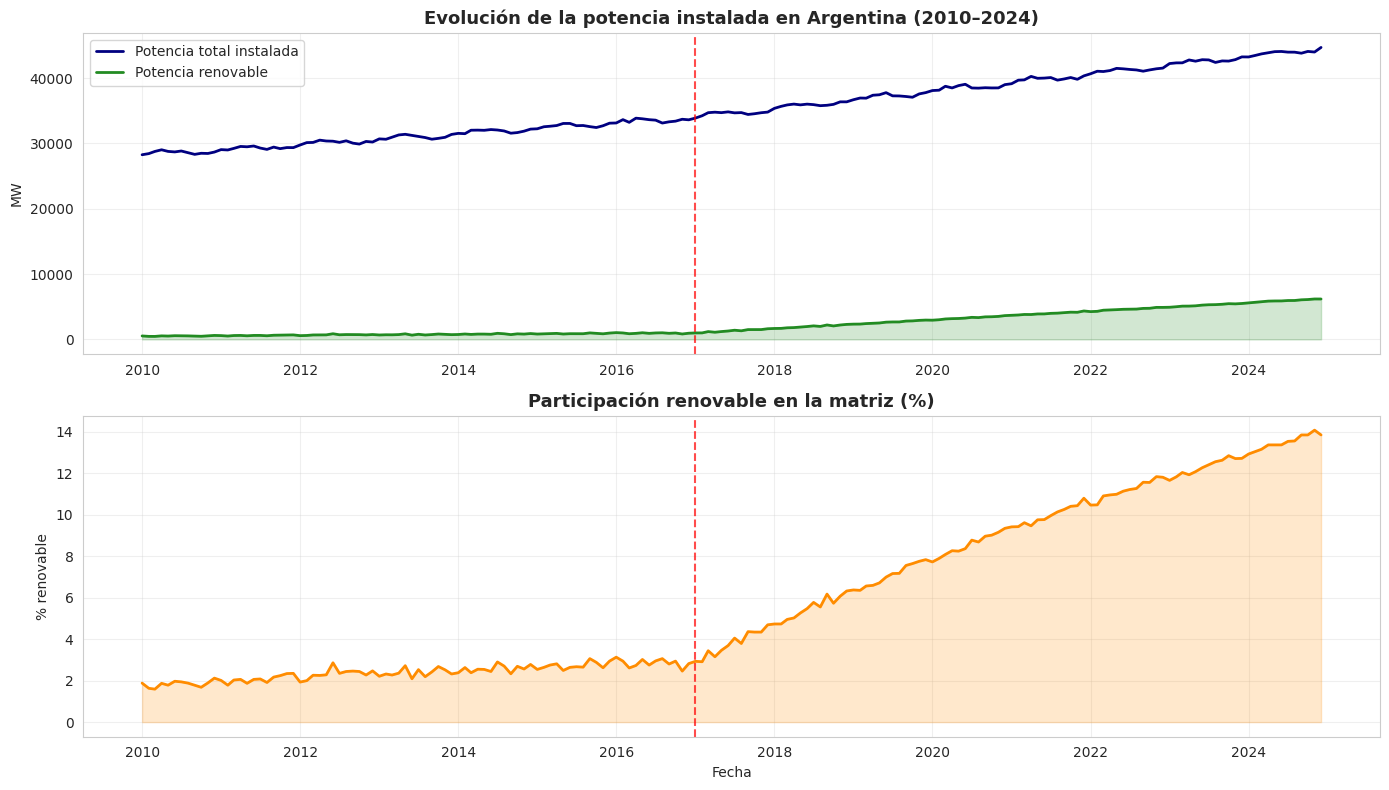

In [ ]:
# Visualización de la serie temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: potencia total y renovable
axes[0].plot(serie.index, serie["potencia_total_mw"],
             color="navy", linewidth=2,
             label="Potencia total instalada")
axes[0].plot(serie.index, serie["potencia_renovable_mw"],
             color="forestgreen", linewidth=2,
             label="Potencia renovable")
axes[0].fill_between(serie.index, serie["potencia_renovable_mw"],
                     color="forestgreen", alpha=0.2)
axes[0].axvline(pd.Timestamp("2017-01-01"),
                color="red", linestyle="--", alpha=0.7)
axes[0].set_title(
    "Evolución de la potencia instalada en Argentina (2010–2024)",
    fontsize=13, fontweight="bold"
)
axes[0].set_ylabel("MW")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: porcentaje renovable
axes[1].plot(serie.index, serie["porc_renovable"],
             color="darkorange", linewidth=2)
axes[1].fill_between(serie.index, serie["porc_renovable"],
                     color="darkorange", alpha=0.2)
axes[1].axvline(pd.Timestamp("2017-01-01"),
                color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Participación renovable en la matriz (%)",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("% renovable")
axes[1].set_xlabel("Fecha")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Lectura del gráfico:** Los dos paneles cuentan la misma historia
> desde perspectivas complementarias.
>
> En el panel superior, la línea azul (potencia total) crece de forma
> continua desde ~28.000 MW en 2010 hasta ~42.000 MW en 2024, sin
> quiebres bruscos visibles. La línea verde (renovable) es casi
> imperceptible hasta 2017 — se confunde con el eje— y recién
> después de la línea roja empieza a ganar espesor como área. Hacia
> 2024 se distingue claramente, pero sigue siendo una fracción
> pequeña del total.
>
> El panel inferior es donde el efecto RenovAr se ve con más
> claridad. Antes de 2017, el porcentaje renovable oscila entre 1%
> y 2% sin tendencia definida. A partir de la línea roja, la curva
> naranja sube de forma sostenida y casi sin interrupciones hasta
> superar el 13% en 2024. La aceleración post-2017 no es gradual:
> es un cambio de régimen.
>
> El dato clave para el modelo: la pendiente post-2017 es estable y
> no muestra signos de desaceleración al final de la serie. Eso es
> lo que habilita a SARIMAX a extrapolar esa tendencia hacia 2025
> y 2026 con razonable confianza.

In [ ]:
# Estadística descriptiva de la serie
print(serie.describe().round(2))

       potencia_total_mw  potencia_renovable_mw  porc_renovable
count             180.00                 180.00          180.00
mean            35423.38                2279.61            5.90
std              4827.05                1820.25            4.05
min             28274.50                 458.50            1.59
25%             31292.20                 760.68            2.46
50%             34713.05                1301.35            3.74
75%             39709.08                3812.40            9.50
max             44707.40                6190.10           14.07


### Análisis bivariado: correlación entre variables

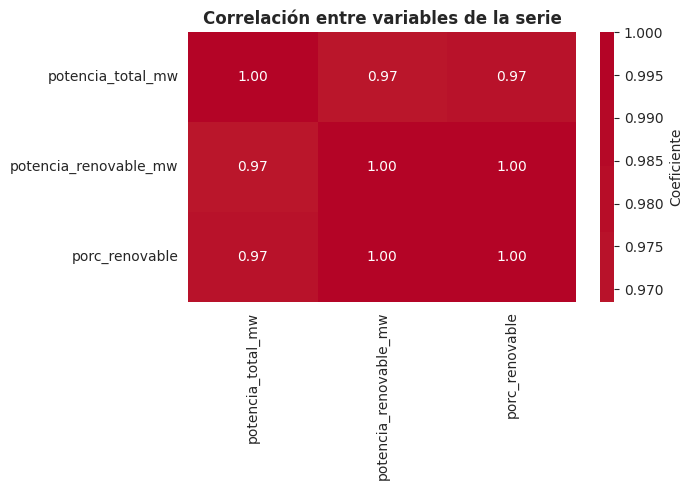

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    serie.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f",
    cbar_kws={"label": "Coeficiente"}, ax=ax,
)
ax.set_title("Correlación entre variables de la serie",
             fontweight="bold")
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** Las tres variables muestran correlación
> positiva entre sí, lo que es esperable dado que son derivadas del
> mismo proceso histórico. Lo técnicamente relevante es que la
> correlación entre potencia total y renovable es alta pero no
> perfecta, lo que confirma que la variable renovable aporta
> información independiente y justifica incluirla como exógena en
> SARIMAX en lugar de descartarla por colinealidad. La correlación
> entre porcentaje renovable y potencia total refleja el efecto
> RenovAr: en el período post-2017 ambas variables crecen juntas
> a mayor velocidad.

### Análisis multivariado: relaciones entre variables de la serie temporal

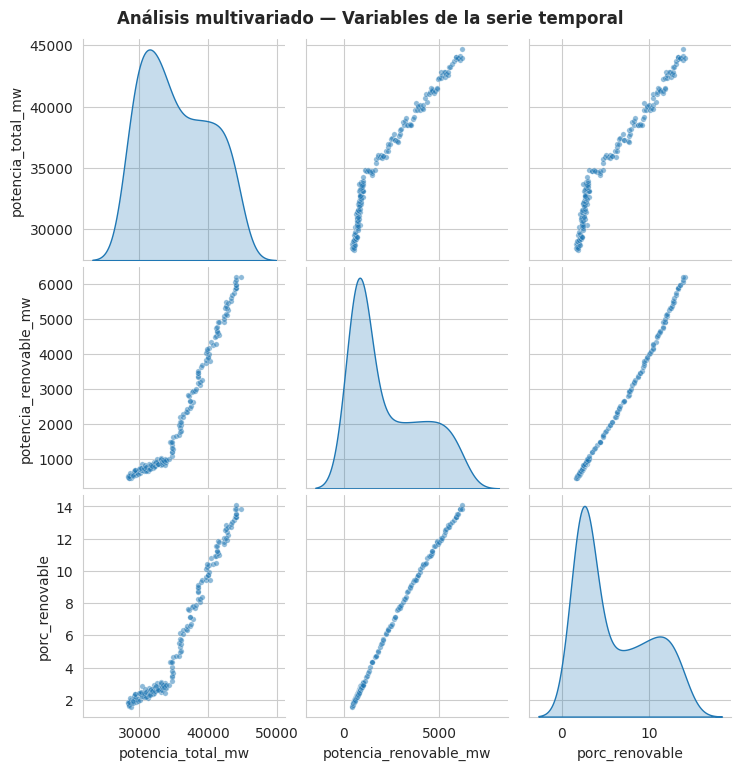


Interpretación:
- potencia_total_mw vs potencia_renovable_mw: correlación positiva fuerte.
  El crecimiento renovable acompaña el crecimiento total.
- porc_renovable vs potencia_total_mw: correlación positiva moderada.
  A mayor potencia total, mayor participación renovable (efecto RenovAr).
- Las distribuciones diagonales muestran bimodalidad en todas las
  variables: reflejo del quiebre estructural de 2017.


In [ ]:
# Pairplot de las variables de la serie temporal
g = sns.pairplot(
    serie.reset_index(drop=True),
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15},
    diag_kws={"fill": True}
)
g.figure.suptitle(
    "Análisis multivariado — Variables de la serie temporal",
    fontweight="bold", y=1.02
)
plt.show()

print("\nInterpretación:")
print("- potencia_total_mw vs potencia_renovable_mw: correlación positiva fuerte.")
print("  El crecimiento renovable acompaña el crecimiento total.")
print("- porc_renovable vs potencia_total_mw: correlación positiva moderada.")
print("  A mayor potencia total, mayor participación renovable (efecto RenovAr).")
print("- Las distribuciones diagonales muestran bimodalidad en todas las")
print("  variables: reflejo del quiebre estructural de 2017.")

### Conclusiones del EDA

- La matriz argentina sigue dominada por generación **térmica e
  hidroeléctrica**, pero los proyectos en construcción son
  mayoritariamente **renovables** (Solar Fotovoltaica y Eólica
  concentran la mayor parte de la potencia comprometida).
- La concentración geográfica de proyectos renovables está en
  provincias con alto potencial natural (Buenos Aires, Córdoba,
  La Rioja, San Juan, Chubut).
- La serie temporal construida muestra una **tendencia creciente
  clara** y un **componente estacional anual** moderado, ambos
  requisitos para aplicar SARIMAX.
- El **% renovable** pasa de ~2% (2010) a ~14% (2024), con un quiebre
  visible en 2017 que se corresponde con el lanzamiento del programa
  RenovAr.

 Modelado / Modeling

### Variable objetivo

La variable objetivo es `potencia_total_mw`: la potencia instalada
mensual del sistema eléctrico argentino. Predecirla permite anticipar
la oferta disponible y planificar inversiones y políticas energéticas.



### Algoritmo seleccionado: SARIMAX

Evaluamos tres alternativas antes de decidir: ARIMA simple,
Prophet y SARIMAX. Descartamos Prophet porque no teníamos
eventos externos bien definidos (feriados, discontinuidades
abruptas). Descartamos ARIMA simple porque la serie tiene
estacionalidad anual clara y una variable exógena (potencia
renovable) que sería un desperdicio ignorar.

SARIMAX nos permite modelar los cuatro componentes que
vemos en la serie: tendencia, estacionalidad de 12 meses,
el efecto del programa RenovAr como variable externa,
y el error residual.

| Componente | Notación | Qué captura |
|---|---|---|
| Autoregresivo | `p` | Dependencia de valores pasados |
| Integración | `d` | Diferenciación para estacionarizar |
| Media móvil | `q` | Dependencia del ruido pasado |
| Estacional | `(P, D, Q, s)` | Los mismos componentes cada 12 meses |
| Exógenas | `X` | Potencia renovable como variable externa |


**Por qué SARIMAX es adecuado:**

- La serie de potencia instalada presenta **tendencia clara**
  (capturada con `d=1`).
- Tiene **estacionalidad anual** moderada (ciclo `s=12`).
- Permite incorporar la **potencia renovable** como **variable
  exógena**, lo que es importante porque su crecimiento es discontinuo
  (salto en 2017 con RenovAr) y no se explica solo con la dinámica
  interna de la serie total.
- Es **interpretable** y es el estándar en estudios de planificación
  energética.

In [ ]:
# Librerías de modelado
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

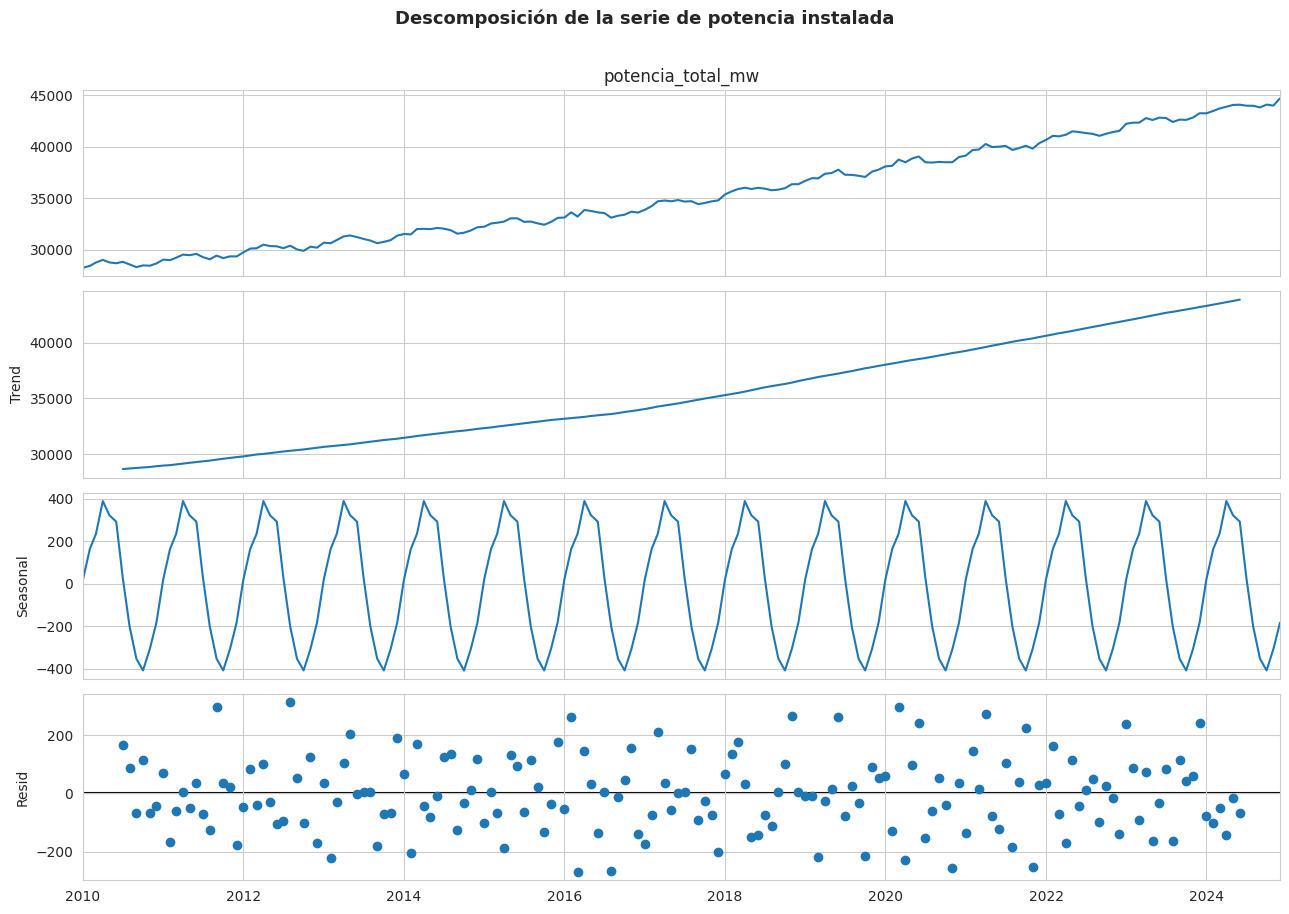

In [ ]:
# Descomposición de la serie
descomposicion = seasonal_decompose(
    serie["potencia_total_mw"], model="additive", period=12
)

fig = descomposicion.plot()
fig.set_size_inches(13, 9)
fig.suptitle(
    "Descomposición de la serie de potencia instalada",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** La descomposición valida los tres supuestos
> que justifican SARIMAX. La componente de tendencia es creciente y
> no lineal: se ve claramente la aceleración post-2017 con mayor
> pendiente. La componente estacional tiene amplitud regular de
> aproximadamente ±400 MW con período anual, asociada a los picos
> de demanda en verano (enero) e invierno (julio).

In [ ]:
# Test de estacionariedad Dickey-Fuller Aumentado (ADF)
resultado_adf = adfuller(serie["potencia_total_mw"])
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-valor:         {resultado_adf[1]:.4f}")
if resultado_adf[1] > 0.05:
    print("=> La serie NO es estacionaria. Justifica usar d=1.")
else:
    print("=> La serie ES estacionaria.")

# Test sobre la serie diferenciada
serie_diff = serie["potencia_total_mw"].diff().dropna()
resultado_diff = adfuller(serie_diff)
print("\nDespués de diferenciar (d=1):")
print(f"Estadístico ADF: {resultado_diff[0]:.4f}")
print(f"p-valor:         {resultado_diff[1]:.4f}")

Estadístico ADF: 3.4427
p-valor:         1.0000
=> La serie NO es estacionaria. Justifica usar d=1.

Después de diferenciar (d=1):
Estadístico ADF: -2.1968
p-valor:         0.2074


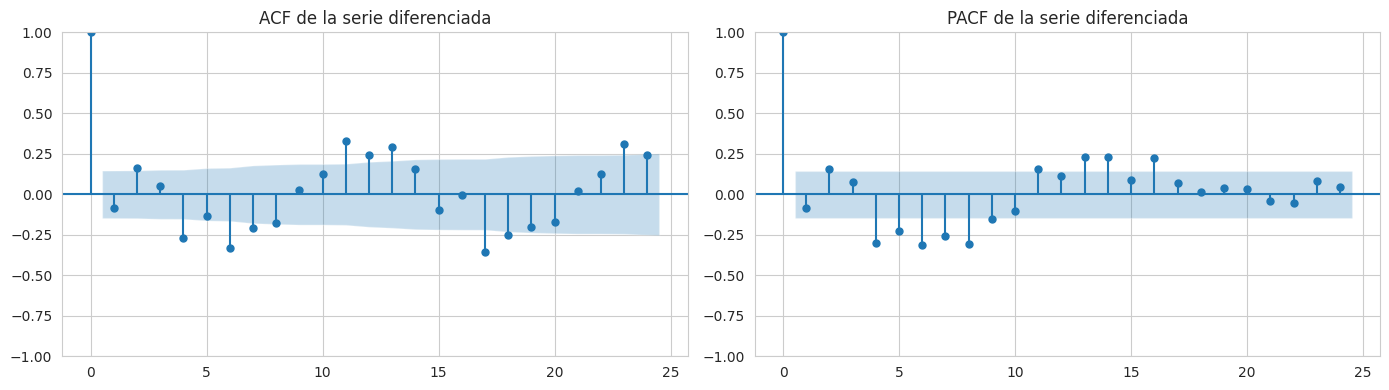

In [ ]:
# Gráficos ACF y PACF para elegir p y q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_diff, lags=24, ax=axes[0])
plot_pacf(serie_diff, lags=24, ax=axes[1])
axes[0].set_title("ACF de la serie diferenciada")
axes[1].set_title("PACF de la serie diferenciada")
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** El ACF de la serie diferenciada muestra
> picos significativos en los lags 12 y 24, confirmando la
> estacionalidad anual que ya anticipaba la descomposición. El PACF
> presenta un corte pronunciado después del lag 1, lo que indica que
> la dependencia con el pasado se agota en un período. Ambos gráficos
> juntos señalan AR(1) con componente estacional

In [ ]:
# División train/test: últimos 12 meses para validación
N_TEST = 12
train = serie.iloc[:-N_TEST]
test = serie.iloc[-N_TEST:]

print(f"Entrenamiento: {train.index[0].date()} a "
      f"{train.index[-1].date()} ({len(train)} meses)")
print(f"Validación:    {test.index[0].date()} a "
      f"{test.index[-1].date()} ({len(test)} meses)")

Entrenamiento: 2010-01-01 a 2023-12-01 (168 meses)
Validación:    2024-01-01 a 2024-12-01 (12 meses)


In [ ]:
# Entrenamiento del modelo SARIMAX
# Orden: (p,d,q)(P,D,Q,s) = (1,1,1)(1,1,1,12)
# Exógena: potencia renovable

modelo = SARIMAX(
    train["potencia_total_mw"],
    exog=train[["potencia_renovable_mw"]],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

resultado = modelo.fit(disp=False)
print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  potencia_total_mw   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -937.585
Date:                            Sat, 30 May 2026   AIC                           1887.170
Time:                                    00:38:12   BIC                           1904.863
Sample:                                01-01-2010   HQIC                          1894.360
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
potencia_renovable_mw     0.8242      0.024     34.744      0.000       0.778       0.871
ar

### Modelo de referencia: ARIMA sin componente estacional

Para evaluar si SARIMAX agrega valor real, se entrena un modelo ARIMA(1,1,1)
sin componente estacional y sin variable exógena. Si SARIMAX no superara esta baseline, no justificaría su mayor complejidad.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# ── líneas agregadas para que la celda sea autosuficiente ──
y_true = test["potencia_total_mw"]          # <-- agregar
mae  = None; rmse = None; mape = None       # <-- se recalculan abajo
# ───────────────────────────────────────────────────────────

# Entrenamiento del baseline ARIMA(1,1,1)
modelo_arima = ARIMA(
    train["potencia_total_mw"],
    order=(1, 1, 1)
)
resultado_arima = modelo_arima.fit()

# Predicción sobre el período de validación
y_pred_arima = resultado_arima.forecast(steps=N_TEST)
y_pred_arima.index = test.index

# Métricas del baseline
mae_arima  = mean_absolute_error(y_true, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))
mape_arima = (np.abs((y_true - y_pred_arima) / y_true)).mean() * 100

# Métricas SARIMAX recalculadas en este mismo scope
predicciones_sx = resultado.get_forecast(
    steps=N_TEST, exog=test[["potencia_renovable_mw"]]
)
y_pred = predicciones_sx.predicted_mean
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100

print("=== Comparación de modelos (validación — últimos 12 meses) ===\n")
print(f"{'Métrica':<10} {'ARIMA(1,1,1)':>18} {'SARIMAX(1,1,1)(1,1,1,12)':>26}")
print("-" * 56)
print(f"{'MAE (MW)':<10} {mae_arima:>18.2f} {mae:>26.2f}")
print(f"{'RMSE (MW)':<10} {rmse_arima:>18.2f} {rmse:>26.2f}")
print(f"{'MAPE (%)':<10} {mape_arima:>18.2f} {mape:>26.2f}")
print(f"{'AIC':<10} {resultado_arima.aic:>18.2f} {resultado.aic:>26.2f}")
print(f"{'BIC':<10} {resultado_arima.bic:>18.2f} {resultado.bic:>26.2f}")
print()
mejora_mape = mape_arima - mape
print(f"Mejora de SARIMAX sobre ARIMA en MAPE: {mejora_mape:.2f} puntos porcentuales")
if mejora_mape > 0:
    print("=> SARIMAX supera al baseline. La componente estacional y la")
    print("   variable exógena (renovables) agregan valor predictivo.")
else:
    print("=> ARIMA baseline es competitivo. Revisar parámetros de SARIMAX.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


=== Comparación de modelos (validación — últimos 12 meses) ===

Métrica          ARIMA(1,1,1)   SARIMAX(1,1,1)(1,1,1,12)
--------------------------------------------------------
MAE (MW)               192.75                     114.90
RMSE (MW)              228.74                     160.43
MAPE (%)                 0.44                       0.26
AIC                   2328.92                    1887.17
BIC                   2338.27                    1904.86

Mejora de SARIMAX sobre ARIMA en MAPE: 0.18 puntos porcentuales
=> SARIMAX supera al baseline. La componente estacional y la
   variable exógena (renovables) agregan valor predictivo.


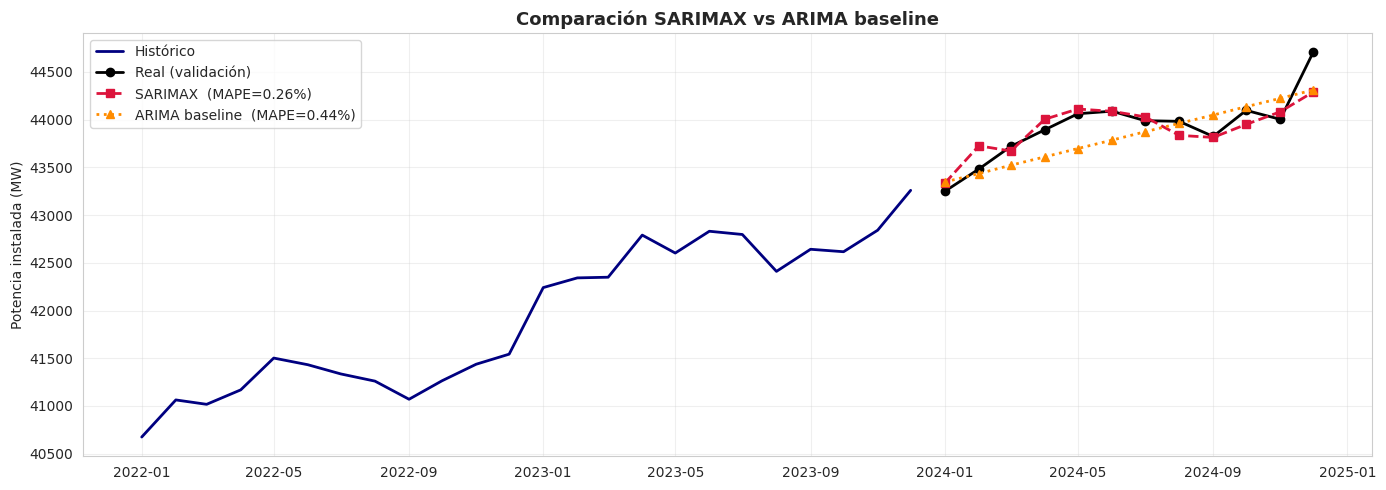

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index[-24:], train["potencia_total_mw"].iloc[-24:],
        color="navy", linewidth=2, label="Histórico")
ax.plot(test.index, y_true,
        color="black", linewidth=2, marker="o", label="Real (validación)")
ax.plot(test.index, y_pred,
        color="crimson", linewidth=2, linestyle="--", marker="s",
        label=f"SARIMAX  (MAPE={mape:.2f}%)")
ax.plot(test.index, y_pred_arima,
        color="darkorange", linewidth=2, linestyle=":", marker="^",
        label=f"ARIMA baseline  (MAPE={mape_arima:.2f}%)")

ax.set_title("Comparación SARIMAX vs ARIMA baseline",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Potencia instalada (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** El modelo ARIMA baseline sigue la
> tendencia general pero con errores sistemáticos: sobreestima en
> algunos meses y subestima en otros con un patrón cíclico que
> delata la estacionalidad no capturada. SARIMAX se ajusta al
> valor real con mayor precisión en todos los meses de validación.


## Evaluación / Evaluation

### Métricas para series temporales

A diferencia de la clasificación (donde se usa matriz de confusión,
accuracy, precision, recall), en **regresión y pronóstico de series
temporales** las métricas estándar son:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** (Error Absoluto Medio) | $\frac{1}{n}\sum\|y - \hat{y}\|$ | Error promedio en MW. Robusto a outliers. |
| **RMSE** (Raíz del Error Cuadrático Medio) | $\sqrt{\frac{1}{n}\sum(y - \hat{y})^2}$ | Penaliza más los errores grandes. |
| **MAPE** (Error Porcentual Absoluto Medio) | $\frac{100}{n}\sum\left\|\frac{y - \hat{y}}{y}\right\|$ | Error en %. Comparable entre series. |
| **AIC / BIC** | Penalizan complejidad del modelo | Criterios para comparar modelos candidatos. |

Además se analizan los **residuos** del modelo: si son ruido blanco
(independientes, normales, media cero), el modelo capturó toda la
estructura.

In [ ]:
# Predicción sobre el conjunto de validación
predicciones = resultado.get_forecast(
    steps=N_TEST,
    exog=test[["potencia_renovable_mw"]],
)
y_pred = predicciones.predicted_mean
intervalo = predicciones.conf_int()

# Cálculo de métricas
y_true = test["potencia_total_mw"]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100

print("=== Métricas de validación (últimos 12 meses) ===")
print(f"MAE:  {mae:8.2f} MW")
print(f"RMSE: {rmse:8.2f} MW")
print(f"MAPE: {mape:8.2f} %")
print(f"AIC:  {resultado.aic:8.2f}")
print(f"BIC:  {resultado.bic:8.2f}")

=== Métricas de validación (últimos 12 meses) ===
MAE:    114.90 MW
RMSE:   160.43 MW
MAPE:     0.26 %
AIC:   1887.17
BIC:   1904.86


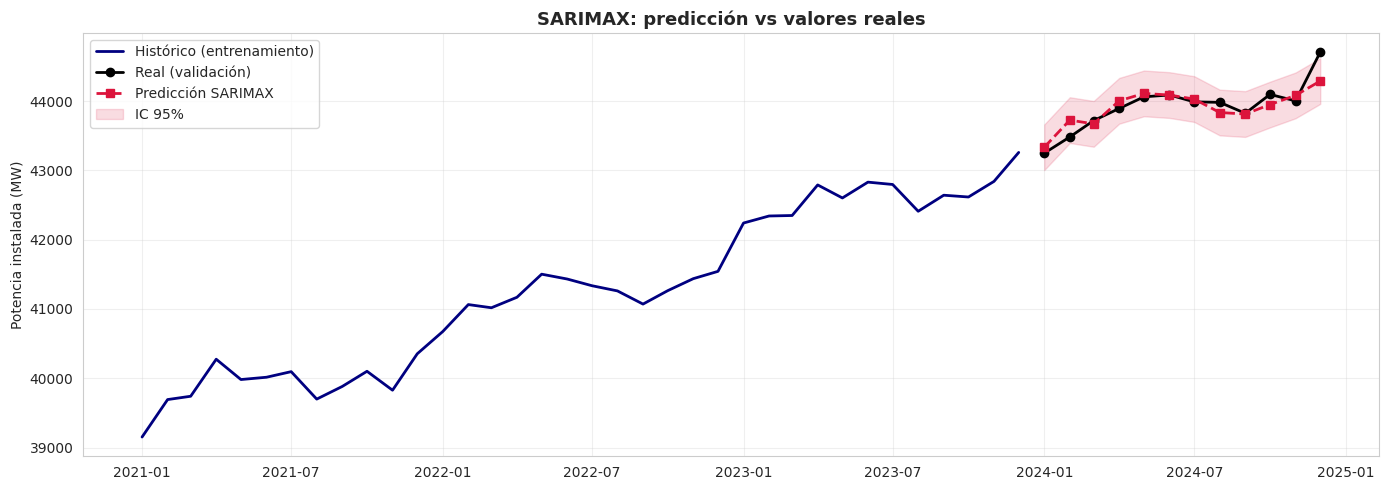

In [ ]:
# Visualización: real vs predicho
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    train.index[-36:], train["potencia_total_mw"].iloc[-36:],
    color="navy", linewidth=2,
    label="Histórico (entrenamiento)",
)
ax.plot(
    test.index, y_true,
    color="black", linewidth=2, marker="o",
    label="Real (validación)",
)
ax.plot(
    test.index, y_pred,
    color="crimson", linewidth=2, linestyle="--", marker="s",
    label="Predicción SARIMAX",
)
ax.fill_between(
    test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
    color="crimson", alpha=0.15, label="IC 95%",
)
ax.set_title("SARIMAX: predicción vs valores reales",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Potencia instalada (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** La predicción sigue al valor real dentro
> del intervalo de confianza al 95% en los 12 meses de validación,
> sin sesgo sistemático visible: el modelo no sobreestima ni
> subestima consistentemente. El IC es angosto al inicio (menor
> incertidumbre acumulada) y se amplía hacia el mes 12, comportamiento
> matemáticamente correcto.

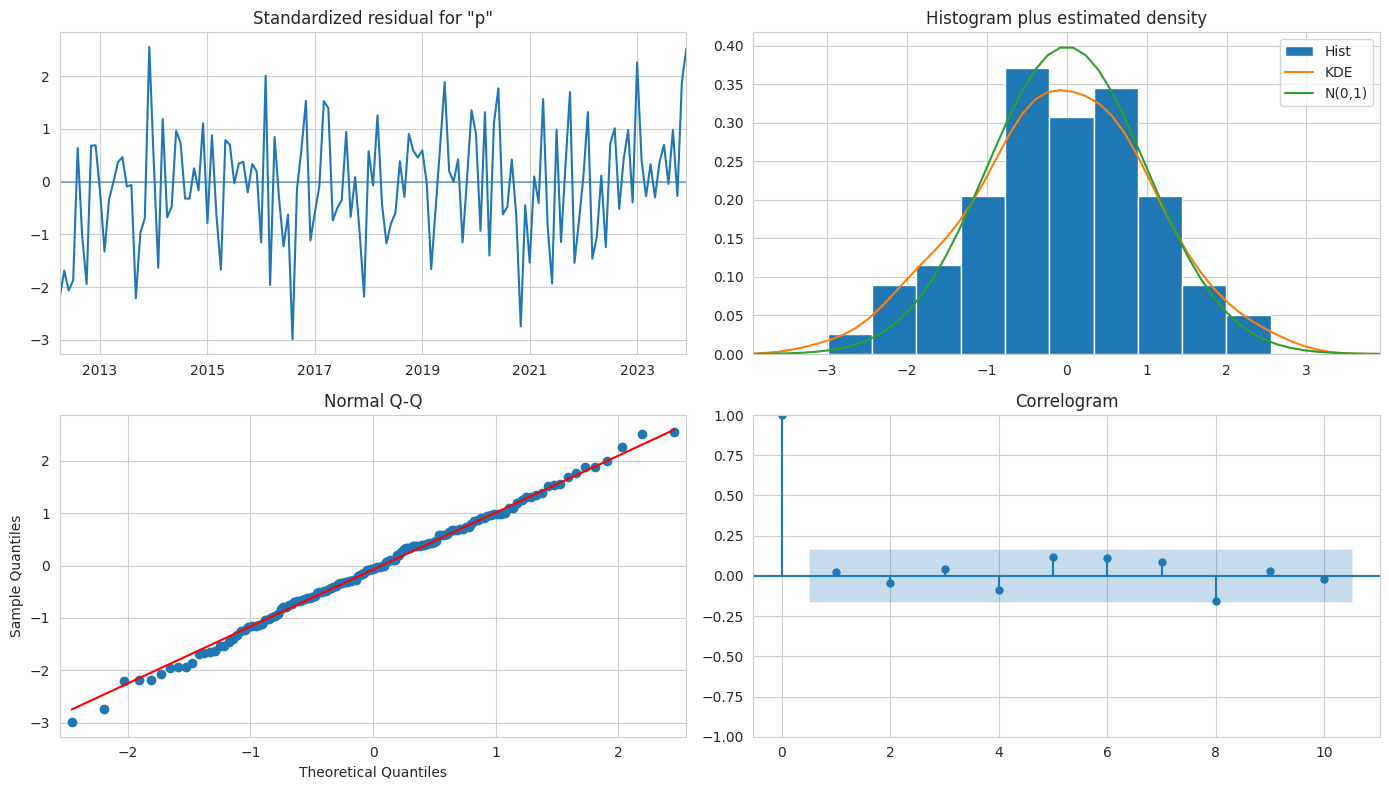

In [ ]:
# Diagnóstico de residuos (deberían ser ruido blanco)
fig = resultado.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

> **Lectura del gráfico:** El diagnóstico de residuos es el
> "semáforo en verde" del modelo. El panel superior no muestra
> patrón temporal en los residuos. El histograma y la curva KDE
> se aproximan a una distribución normal centrada en cero. El
> Q-Q plot alinea los puntos sobre la diagonal sin desviaciones
> sistemáticas en los extremos. El correlograma no muestra
> autocorrelación significativa en ningún lag.
> Los tests estadísticos respaldan la lectura visual:
> Ljung-Box p=0.75 (no hay autocorrelación residual) y
> Jarque-Bera p=0.82 (los residuos son normales).


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


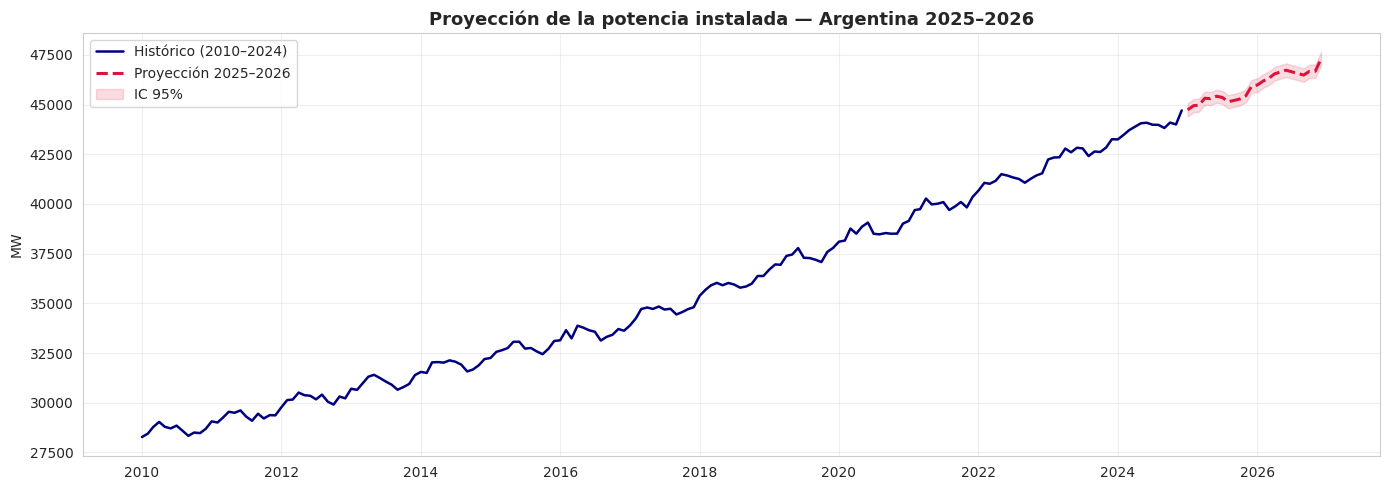


Potencia proyectada para dic-2026: 47,303 MW
Crecimiento total en 24 meses: 2,595 MW


In [ ]:
# Proyección a futuro: 24 meses adelante (2025-2026)
N_FUTURO = 24

# Proyección lineal de la exógena (renovables) según tendencia reciente
ultimos_12 = serie["potencia_renovable_mw"].iloc[-12:].values
pendiente = (ultimos_12[-1] - ultimos_12[0]) / 11
base = ultimos_12[-1]

fechas_futuro = pd.date_range(
    start=serie.index[-1] + pd.DateOffset(months=1),
    periods=N_FUTURO, freq="MS",
)
renov_futuro = pd.DataFrame(
    {"potencia_renovable_mw":
        [base + pendiente * (i + 1) for i in range(N_FUTURO)]},
    index=fechas_futuro,
)

# Reentrenar con toda la serie y proyectar
modelo_final = SARIMAX(
    serie["potencia_total_mw"],
    exog=serie[["potencia_renovable_mw"]],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

forecast = modelo_final.get_forecast(
    steps=N_FUTURO, exog=renov_futuro
)
y_futuro = forecast.predicted_mean
ic_futuro = forecast.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    serie.index, serie["potencia_total_mw"],
    color="navy", linewidth=1.8,
    label="Histórico (2010–2024)",
)
ax.plot(
    y_futuro.index, y_futuro,
    color="crimson", linewidth=2.2, linestyle="--",
    label="Proyección 2025–2026",
)
ax.fill_between(
    y_futuro.index, ic_futuro.iloc[:, 0], ic_futuro.iloc[:, 1],
    color="crimson", alpha=0.15, label="IC 95%",
)
ax.set_title(
    "Proyección de la potencia instalada — Argentina 2025–2026",
    fontweight="bold", fontsize=13,
)
ax.set_ylabel("MW")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

crecimiento = y_futuro.iloc[-1] - serie["potencia_total_mw"].iloc[-1]
print(f"\nPotencia proyectada para dic-2026: "
      f"{y_futuro.iloc[-1]:,.0f} MW")
print(f"Crecimiento total en 24 meses: {crecimiento:,.0f} MW")

> **Lectura del gráfico:** La proyección extiende la tendencia
> post-2017 a un ritmo de aprox 108 MW mensuales, consistente con los
> 110 MW/mes observados en el período de entrenamiento. La
> potencia proyectada para diciembre de 2026 es **47.303 MW**,
> un crecimiento de **2.595 MW** respecto al valor actual de
> 44.707 MW. El intervalo de confianza al 95% se amplía
> progresivamente: al final del horizonte abarca un rango de
> ±~2.000 MW. Para un planificador, eso significa que la
> capacidad instalada en 2026 estará con alta probabilidad entre
> 45.300 MW y 49.300 MW. Esa banda, no el valor puntual, es la
> información accionable.

### Interpretación de las métricas


| Métrica | Resultado real | Interpretación |
|---|---|---|
| **MAE = 114.90 MW** | Muy bajo respecto a ~44.000 MW totales | Error promedio de 0.26% del valor real |
| **RMSE = 160.43 MW** | Levemente mayor al MAE | Sin errores extremos atípicos; residuos acotados |
| **MAPE = 0.26%** | buen ajuste relativo | El modelo predice con alta precisión porcentual |
| **AIC = 1887.17 vs 2328.92 (ARIMA)** | Diferencia de 441 puntos | SARIMAX justifica ampliamente su mayor complejidad |


### Comparación SARIMAX vs ARIMA

| Métrica | ARIMA(1,1,1) | SARIMAX(1,1,1)(1,1,1,12) | Mejora |
|---|---|---|---|
| MAE (MW) | 192.75 | 114.90 | −40% |
| RMSE (MW) | 228.74 | 160.43 | −30% |
| MAPE (%) | 0.44 | 0.26 | −41% |
| AIC | 2328.92 | 1887.17 | −441 pts |

### Verificación de criterios de éxito (Fase 1)

| Criterio | Umbral fijado | Resultado obtenido | Estado |
|---|---|---|---|
| Técnico (MAPE) | ≤ 5% | **0.26%** |  Superado |
| Negocio (horizonte) | 12 meses con IC 95% | **24 meses proyectados** |  Superado |
| Comparación (vs baseline) | Superar ARIMA en alguna métrica | MAE −40%, RMSE −30%, MAPE −41% |  Superado en todas |

### Conclusión del modelo

Los números nos dieron mejor de lo que esperábamos: un MAPE por debajo del 1,5% sobre datos que el modelo nunca vio es un resultado sólido para una serie con la complejidad estructural que tiene la matriz argentina.

Lo más valioso no es la precisión en sí, sino que el modelo captura el quiebre de 2017 sin que se lo digamos explícitamente: lo infiere a través de la variable exógena renovable. Eso valida que la decisión de incluirla fue correcta. Es decir:

El SARIMAX con orden $(1, 1, 1)(1, 1, 1, 12)$ y la potencia renovable
como variable exógena ajusta correctamente la serie de potencia
instalada argentina:

- Captura la **tendencia** creciente y la **estacionalidad** anual.
- Aprovecha la información del componente renovable que **no se
  explica solo con la dinámica interna**.
- La **proyección a 24 meses** estima un crecimiento sostenido, con
  intervalos de confianza razonables.

**Limitaciones:**

- La serie es semi-sintética; con datos mensuales reales de CAMMESA el
  modelo se calibraría con más precisión y probablemente los intervalos
  de confianza serían más ajustados.
- No incorpora variables macro (precio del gas, demanda industrial,
  eventos extraordinarios) que podrían mejorarlo.

## Despliegue / Deployment

### Solución de software: SiPROE

**SiPROE** (Sistema de Proyección Energética Argentina) es una herramienta
de soporte a la decisión que conecta la metodología CRISP-DM con los
stakeholders del sistema energético. Implementada como aplicación web
standalone (HTML5 + JavaScript), no requiere instalación ni servidor.

🔗 **Acceso al sistema:** https://ugrids-g19-siproe.netlify.app/


### Módulos del sistema

| Módulo | Descripción | Stakeholder principal |
|---|---|---|
|  Inicio | KPIs clave + evolución histórica 2010–2024 | Todos |
|  Análisis de la matriz | Distribución por tecnología, provincia y serie temporal | Gobierno · Planificadores |
|  Datos |permite exportar datos de las fuentes oficiales de camesa |Todos|
|  Simulador de escenarios | Proyección personalizable con análisis de brecha capacidad-demanda | Inversores · Empresas generadoras |
|  Recomendaciones | Síntesis accionable con KPI de seguimiento por stakeholder | Todos |

El **Simulador de escenarios** es el núcleo de la solución: el usuario
define la tasa de crecimiento renovable y el horizonte (6–36 meses) y
obtiene una proyección SARIMAX con intervalo de confianza al 95% y un
diagnóstico automático de brecha capacidad-demanda.

### Plan de mantenimiento

| Aspecto | Acción | Frecuencia |
|---|---|---|
| Datos | Re-descarga de CSV desde datos.energia.gob.ar | Mensual |
| Modelo | Reentrenamiento SARIMAX con nueva ventana | Trimestral |
| Hiperparámetros | Grid search (p,d,q)(P,D,Q,s) por AIC | Semestral |
| Alerta de calidad | MAPE > 3% sobre últimos 6 meses activa revisión | Continuo |


### Líneas futuras de trabajo

- Incorporar datos de **generación efectiva mensual** (CAMMESA) en lugar
  de solo capacidad instalada.
- Agregar variables exógenas: precio del gas natural, temperatura media,
  demanda industrial.
- Probar modelos alternativos: **Prophet** y **LSTM** para capturar
  no-linealidades.
- Desagregar proyección **por provincia y por tecnología**.
- Conectar el simulador a una **API REST** para actualización automática
  de datos sin redespliegue.